In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import TRAIN_A, TRAIN_B

print("Training Set A:", TRAIN_A)
print("Training Set B:", TRAIN_B)

Training Set A: C:\TwinSepsis\dataset\physionet.org\files\challenge-2019\1.0.0\training\training_setA
Training Set B: C:\TwinSepsis\dataset\physionet.org\files\challenge-2019\1.0.0\training\training_setB


In [2]:
files_A = list(TRAIN_A.glob("*.psv"))
files_B = list(TRAIN_B.glob("*.psv"))

print("Training Set A:", len(files_A))
print("Training Set B:", len(files_B))
print("Total patients:", len(files_A) + len(files_B))

Training Set A: 20336
Training Set B: 20000
Total patients: 40336


In [3]:
def summarize_patient(file_path):
    df = pd.read_csv(file_path, sep="|")

    return {
        "patient_id": file_path.stem,
        "hours": len(df),
        "sepsis_hours": int(df["SepsisLabel"].sum()),
        "has_sepsis": int(df["SepsisLabel"].max() == 1),
        "set": file_path.parent.name
    }

In [4]:
summary = summarize_patient(files_A[0])

summary

{'patient_id': 'p000001',
 'hours': 54,
 'sepsis_hours': 0,
 'has_sepsis': 0,
 'set': 'training_setA'}

In [5]:
all_files = files_A + files_B

patient_summaries = []

for i, file_path in enumerate(all_files):

    patient_summaries.append(
        summarize_patient(file_path)
    )

    if (i + 1) % 5000 == 0:
        print(f"Processed {i + 1:,} patients")

Processed 5,000 patients
Processed 10,000 patients
Processed 15,000 patients
Processed 20,000 patients
Processed 25,000 patients
Processed 30,000 patients
Processed 35,000 patients
Processed 40,000 patients


In [6]:
patient_summary_df = pd.DataFrame(patient_summaries)

patient_summary_df.head()

,patient_id,hours,sepsis_hours,has_sepsis,set
0,p000001,54,0,0,training_setA
1,p000002,23,0,0,training_setA
2,p000003,48,0,0,training_setA
3,p000004,29,0,0,training_setA
4,p000005,48,0,0,training_setA


In [7]:
patient_summary_df.shape

(40336, 5)

In [8]:
patient_summary_df.describe()

,hours,sepsis_hours,has_sepsis
count,40336.000000,40336.000000,40336.000000
mean,38.482001,0.692086,0.072689
std,22.795923,2.481476,0.259629
min,8.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000
50%,38.000000,0.000000,0.000000
75%,47.000000,0.000000,0.000000
max,336.000000,10.000000,1.000000


In [9]:
patient_summary_df["has_sepsis"].value_counts()

has_sepsis
0    37404
1     2932
Name: count, dtype: int64

In [10]:
septic_patients = patient_summary_df["has_sepsis"].sum()
total_patients = len(patient_summary_df)

print("Total patients:", total_patients)
print("Patients with sepsis:", septic_patients)
print("Patients without sepsis:", total_patients - septic_patients)

print(
    "Percentage of patients with sepsis:",
    septic_patients / total_patients * 100
)

Total patients: 40336
Patients with sepsis: 2932
Patients without sepsis: 37404
Percentage of patients with sepsis: 7.268940896469656


In [11]:
total_hours = patient_summary_df["hours"].sum()
sepsis_hours = patient_summary_df["sepsis_hours"].sum()
non_sepsis_hours = total_hours - sepsis_hours

print("Total ICU hours:", total_hours)
print("Sepsis-positive hours:", sepsis_hours)
print("Sepsis-negative hours:", non_sepsis_hours)

print(
    "Sepsis-positive hour percentage:",
    sepsis_hours / total_hours * 100
)

Total ICU hours: 1552210
Sepsis-positive hours: 27916
Sepsis-negative hours: 1524294
Sepsis-positive hour percentage: 1.798467990800214


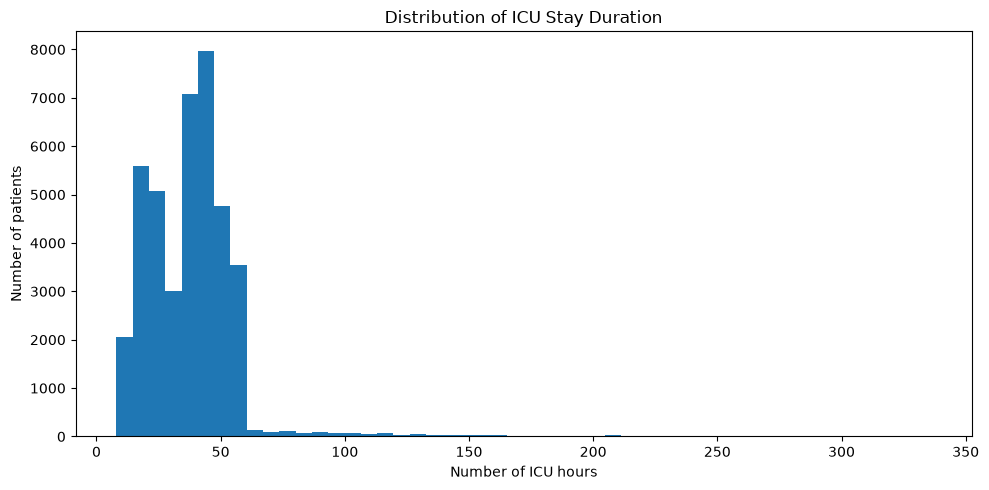

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(
    patient_summary_df["hours"],
    bins=50
)

plt.xlabel("Number of ICU hours")
plt.ylabel("Number of patients")
plt.title("Distribution of ICU Stay Duration")

plt.tight_layout()
plt.show()

In [13]:
patient_summary_df.groupby("set").agg(
    patients=("patient_id", "count"),
    total_hours=("hours", "sum"),
    septic_patients=("has_sepsis", "sum"),
    sepsis_hours=("sepsis_hours", "sum")
)

,patients,total_hours,septic_patients,sepsis_hours
set,,,,
training_setA,20336,790215,1790,17136
training_setB,20000,761995,1142,10780


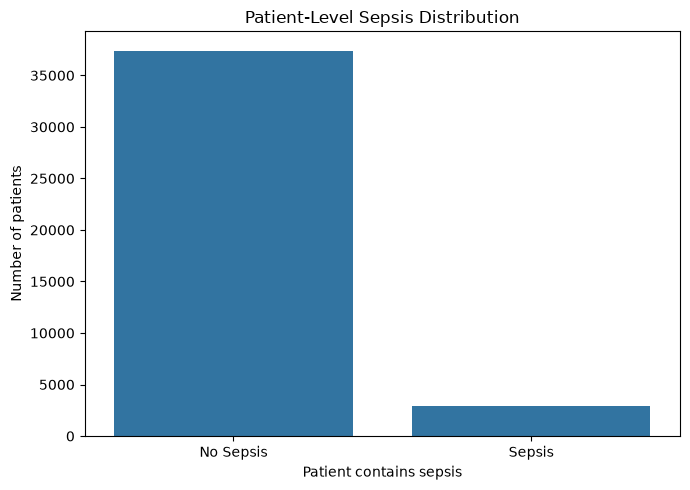

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=patient_summary_df,
    x="has_sepsis"
)

plt.xlabel("Patient contains sepsis")
plt.ylabel("Number of patients")
plt.title("Patient-Level Sepsis Distribution")

plt.xticks(
    [0, 1],
    ["No Sepsis", "Sepsis"]
)

plt.tight_layout()
plt.show()

In [15]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

patient_summary_df.to_csv(
    RESULTS_DIR / "patient_summary.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "patient_summary.csv")

Saved: c:\TwinSepsis\results\patient_summary.csv
